In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()

# Add 2 more columns,
# - target at previous trial
# - response at previous trial

rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

# Modeling setup:
# - emissions : resp
# - inputs : t_calib, prev_target, prev_resp

# Training a global model - use all data combined
emissions = jnp.array(np.deg2rad(rdf['resp'].values.reshape(-1, 120,1)))
inputs = jnp.array(np.deg2rad(rdf[['t_calib', 'prev_target', 'prev_resp']].values.reshape(-1, 120,3)))

emissions.shape, inputs.shape

((288, 120, 1), (288, 120, 3))

In [4]:
with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)

with open('./caches/global_crossval.pkl', 'rb') as f:
    global_crossval = pickle.load(f)

with open('./caches/sub_crossval_results.pkl', 'rb') as f:
    crossval_results = pickle.load(f)
    
with open('./caches/subject_params.pkl', 'rb') as f:
    subject_params = pickle.load(f)
    
with open('./caches/one_state_crossval_result.pkl', 'rb') as f:
    ost_crossval = pickle.load(f)

In [5]:
num_states, input_dim, emission_dim = 2, 3, 1

## Global viz

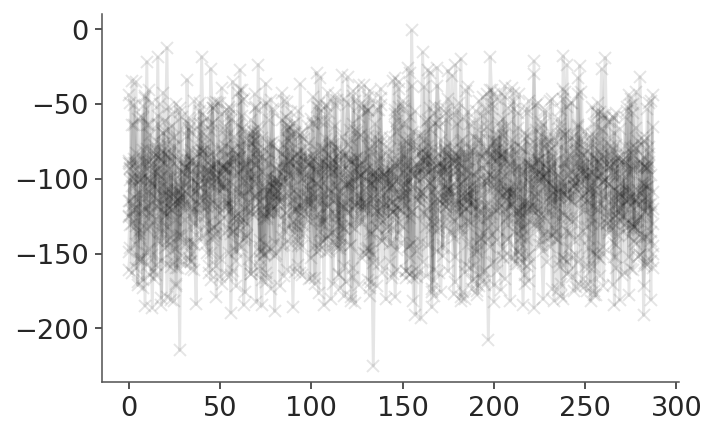

In [6]:
plt.figure(figsize=(5, 3))
for key, value in global_crossval.items():
    plt.plot(value, "-kx", label = f"states = {key}", alpha = 0.1)

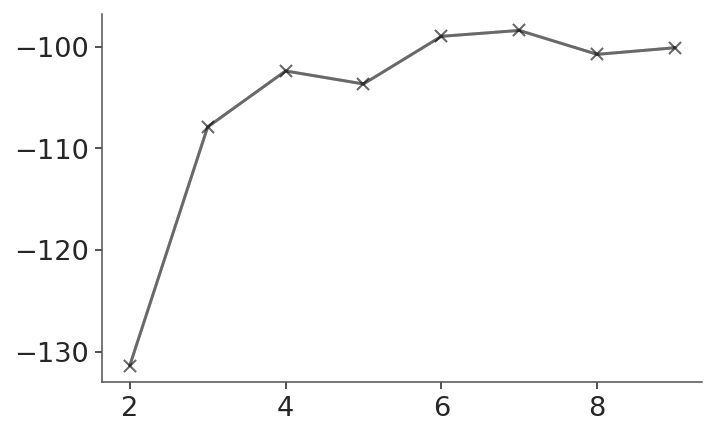

In [7]:
plt.figure(figsize=(5, 3))
dt = [global_crossval[a].mean() for a in global_crossval.keys()]
for key, value in global_crossval.items():
    plt.plot(np.arange(2,10),dt, "-kx", label = f"states = {key}", alpha = 0.1)

## Crossval viz

In [8]:
full_crossval = crossval_results.copy()
for idx in range(12):
    full_crossval[idx][1] = ost_crossval[idx][1].reshape(-1)

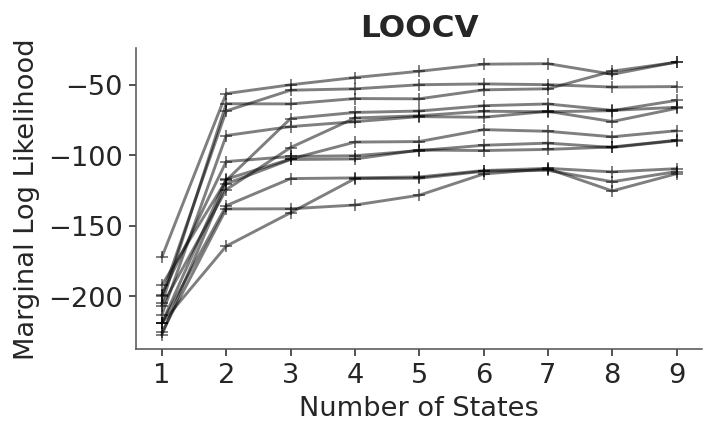

In [9]:
# Lets take a look at the cross validated log likelihoods
plt.figure(figsize=(5, 3))
sb = []
for sub_idx in full_crossval.keys():
    subj_data = full_crossval[sub_idx]
    
    s = []
    for nstate in range(1,10):
        
        state_data = np.mean(subj_data[nstate])
        s.append(state_data)
    sb.append(s)
    plt.plot( s, '-k+', alpha=0.5)
    
# marginal likelihoods in y axis
plt.xticks(np.arange(9), np.arange(1, 10))
plt.xlabel('Number of States')
plt.ylabel('Marginal Log Likelihood')
plt.title('LOOCV')
plt.show()

## AIC BIC viz

In [10]:
all_cv = []
all_ll = []

for idx in range(12):
    sb = []
    ll = []
    for nstate in range(1,10):
        sb.append(crossval_results[idx][nstate].mean())
        ll.append(crossval_results[idx][nstate])
    all_cv.append(sb)
    all_ll.append(ll)

all_cv = np.array(all_cv)
all_ll = np.array(all_ll)

In [11]:
all_aic, all_bic = [], []
for idx, subjects in enumerate(all_ll):
    aic, bic = [], []
    for i, (n_state, ll) in enumerate(zip(np.arange(1,10), subjects)):
        a, b = calc_aic_bic_vhmm(n_state = n_state, log_likelihood = ll, input_dim = input_dim, output_dim = emission_dim, T = 120)
        # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
        aic.append(a)
        bic.append(b)
    all_aic.append(aic)
    all_bic.append(bic)
all_aic, all_bic = np.array(all_aic), np.array(all_bic)

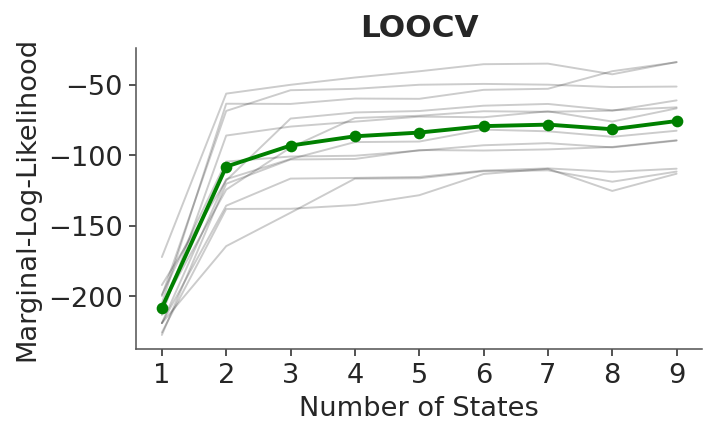

In [12]:
plt.figure(figsize=(5, 3))

# for subjects in all_ll:
#     for x in np.arange(1, 10):
#         plt.scatter([x] * len(subjects[x-1]), subjects[x-1],s=5, alpha=0.05, color="lightgray")

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(1, 10), subjects, "-k", alpha=0.2, linewidth=1)
    # plt.plot(np.arange(1, 10), subjects, alpha=1, label=f"{idx+1}")

plt.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="Mean", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(1, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

# plt.legend()
plt.show()

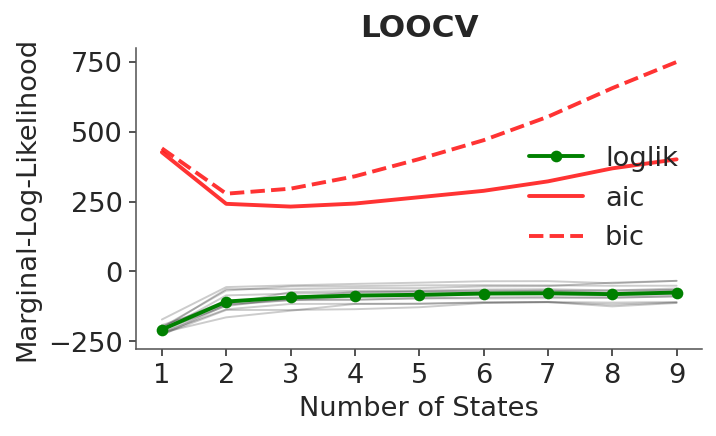

In [13]:
plt.figure(figsize=(5, 3))

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(1, 10), subjects, "-k", alpha=0.2, linewidth=1)

plt.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="loglik", linewidth=2, markersize=5)
plt.plot(np.arange(1, 10), np.array(all_aic).mean(axis=(0,2)), "-r", alpha=.8, label="aic", linewidth=2, markersize=5)
plt.plot(np.arange(1, 10), np.array(all_bic).mean(axis=(0,2)), "--r", alpha=.8, label="bic", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(1, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

plt.legend()
plt.show()

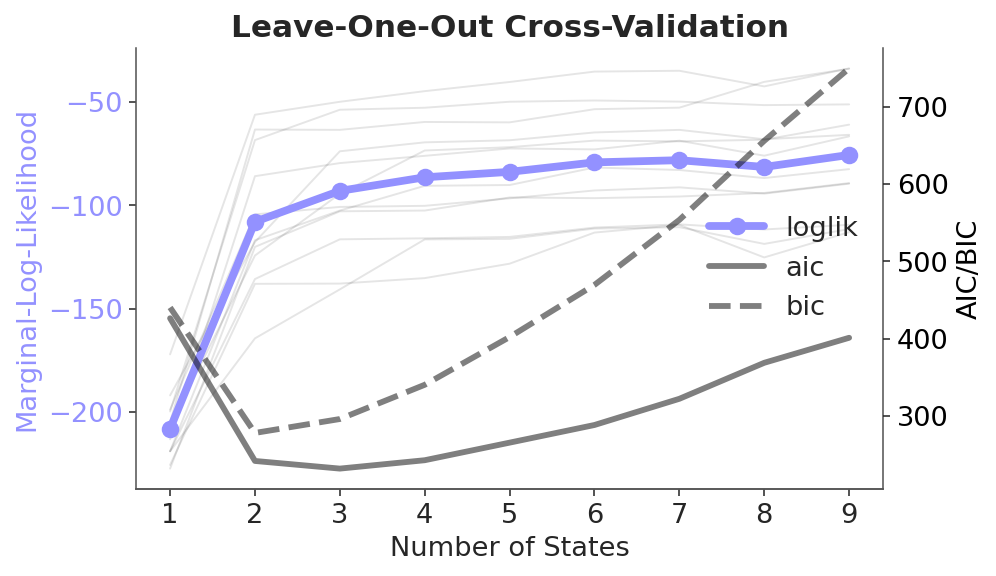

In [14]:
fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot each individual log-likelihood curve on ax1 (left axis)
for subjects in all_cv:
    ax1.plot(np.arange(1, 10), subjects, "-k", alpha=0.1, linewidth=1)

# Plot the mean log-likelihood on ax1 in green
ax1.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-o", color="#9391ff",
         alpha=1, label="loglik", linewidth=4, markersize=8)
ax1.set_xlabel("Number of States")
ax1.set_ylabel("Marginal-Log-Likelihood", color="#9391ff")
ax1.tick_params(axis='y', labelcolor="#9391ff")
ax1.set_xticks(np.arange(1, 10))
ax1.set_title("Leave-One-Out Cross-Validation")

# Create a second y-axis sharing the same x-axis for AIC/BIC
ax2 = ax1.twinx()
ax2.plot(np.arange(1, 10), np.array(all_aic).mean(axis=(0,2)), "-k", 
         alpha=0.5, label="aic", linewidth=3, markersize=5)
ax2.plot(np.arange(1, 10), np.array(all_bic).mean(axis=(0,2)), "--k", 
         alpha=0.5, label="bic", linewidth=3, markersize=5)
ax2.set_ylabel("AIC/BIC", color="k")
ax2.tick_params(axis='y', labelcolor="k")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

# Axis border off
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.show()

/tmp/ipykernel_105150/930397522.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


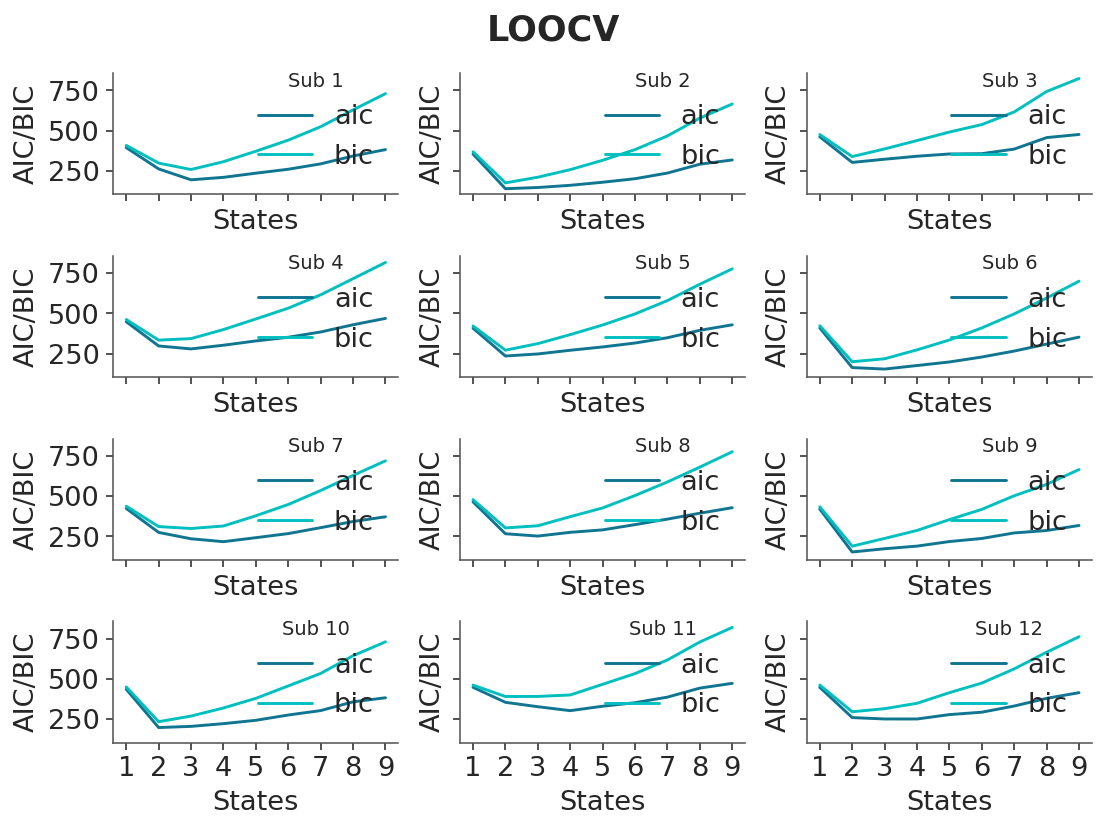

In [15]:
fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

# for idx, subjects in enumerate(all_ll):
#     for x in np.arange(1, 10):
#         ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, (aic, bic) in enumerate(zip(all_aic, all_bic)):
    # plt.plot(np.arange(1, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(1, 10), aic.mean(axis=1), alpha=1, label=f"aic")
    ax[idx].plot(np.arange(1, 10), bic.mean(axis=1), alpha=1, label=f"bic")
    
    ax[idx].legend(frameon=False, loc="lower right", title = f"Sub {idx+1}")
    ax[idx].set_xticks(np.arange(1, 10))
    
    ax[idx].set_ylabel("AIC/BIC")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

plt.tight_layout()

## State occupancy viz

In [16]:
st = 2
sb = 8
ts = subject_params[sb][st]
model = CircularRegressionHMM(st, input_dim, emission_dim)

In [17]:
mls = []
for e, i in zip(emissions.reshape(12, 4 * 6, 120, 1)[sb], inputs.reshape(12, 4 * 6, 120, 3)[sb]):
    most_likely_states = model.most_likely_states(ts, e, inputs=i)
    mls.append(most_likely_states)
    
mls = np.array(mls)

In [18]:
# Count occurrences for each class (assuming classes 0, 1, 2)
counts = np.bincount(mls.flatten(), minlength=st)
proportions = counts / mls.size  # mls.size is 2880 in this case

print("Overall proportions:", proportions)

Overall proportions: [0.68298611 0.31701389]


<Axes: >

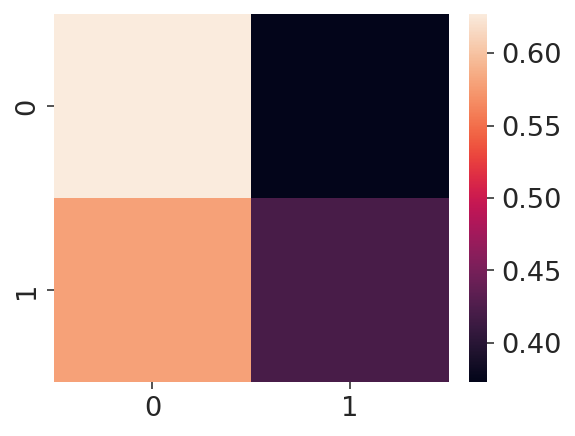

In [19]:
plt.figure(figsize=(4,3))
sns.heatmap(ts.transitions.transition_matrix)

In [20]:
ts.emissions

ParamsCircularRegressionHMMEmissions(weights=Array([[[ 0.88860506, -0.05285346,  0.10514485]],

       [[-0.03915995,  0.0332466 ,  0.01942015]]], dtype=float32), biases=Array([[0.03294317],
       [1.4244837 ]], dtype=float32), covs=Array([[[0.03265357]],

       [[0.21754885]]], dtype=float32))